# **Trabajo Práctico N° 2 - Aprendizaje Automático II - 2024**

### **Redes Recurrentes**
**PROBLEMA 1 - Detección de idioma**

---
**Alumno:**


*   **Fontana Gustavo**

**Legajo:**


*   **F-3749/4**


## **Librerías**

In [ ]:
!apt-get install tree -qq

Selecting previously unselected package tree.
(Reading database ... 124926 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
import os
import json
import random
import numpy as np
import seaborn as sns
import gdown
import soundfile as sf
from pathlib import Path
import IPython.display as ipd
from collections import Counter
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras import models, layers
from tensorflow.keras.layers import StringLookup
from tensorflow.keras import regularizers
import zipfile

## **Ajustes iniciales**

In [ ]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

1 Physical GPUs, 1 Logical GPUs


## **Construcción del dataset**

El dataset contiene audios en formato wav, es un subconjunto de un dataset más grande y contiene ejemplos hablados en cuatro idiomas diferentes, Español, Inglés, Francés y Japonés.

In [ ]:
# Configuración de los datasets
url = "https://drive.google.com/uc?id=1FRiWV7pV9qAJ2XBSpH1HxVtffs-Xabr1"
output_path = "/content/audio_dataset.zip"
extract_path = "/content/audio_dataset"

# Descargar el archivo
gdown.download(url, output_path, quiet=False)

# Extraer el archivo ZIP
with zipfile.ZipFile(output_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Eliminar el archivo ZIP después de extraerlo
if os.path.exists(output_path):
    os.remove(output_path)

Downloading...
From (original): https://drive.google.com/uc?id=1FRiWV7pV9qAJ2XBSpH1HxVtffs-Xabr1
From (redirected): https://drive.google.com/uc?id=1FRiWV7pV9qAJ2XBSpH1HxVtffs-Xabr1&confirm=t&uuid=377ae54f-5be1-40de-a32d-e4ec3d6d112f
To: /content/audio_dataset.zip
100%|██████████| 488M/488M [00:07<00:00, 64.6MB/s]


In [ ]:
!tree -L 2 /content/audio_dataset

/content/audio_dataset
└── ds_reducido
    ├── Español
    ├── Francés
    ├── Inglés
    └── Japonés

5 directories, 0 files


Como los archivos de audio se encuentran distribuídos en subdirectorios de su idioma correspondiente, se pude usar `keras.utils.audio_dataset_from_directory` para cargarlos al entorno.

In [ ]:
# Cargar el dataset
data_dir='/content/audio_dataset/ds_reducido'

train, val_test = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=16,
    validation_split=0.3,
    seed=0,
    output_sequence_length=160000,
    subset='both')

val_size = int(0.5 * len(val_test))
val = val_test.take(val_size)
test = val_test.skip(val_size)

Found 2000 files belonging to 4 classes.
Using 1400 files for training.
Using 600 files for validation.


In [ ]:
# Inspección del dataset
print(f'{train.element_spec}\n')

# Verificar las características de un audio
file_path = "/content/audio_dataset/ds_reducido/Español/10005668950815513748.wav"
info = sf.info(file_path)
print(info)

(TensorSpec(shape=(None, 160000, None), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

/content/audio_dataset/ds_reducido/Español/10005668950815513748.wav
samplerate: 16000 Hz
channels: 1
duration: 5.760 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]


In [ ]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train.map(squeeze, tf.data.AUTOTUNE)
val_ds = val.map(squeeze, tf.data.AUTOTUNE)
test_ds = test.map(squeeze, tf.data.AUTOTUNE)

# Formato de salida
print(f'{train_ds.element_spec}\n')

for example_audio, example_labels in train_ds.take(1):
  print(f'Formato del audio: {example_audio.shape}')
  print(f'Formato de las etiquetas: {example_labels.shape}')

(TensorSpec(shape=(None, 160000), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Formato del audio: (16, 160000)
Formato de las etiquetas: (16,)


Al tratarse de audios con un solo canal por clip, se descarta el eje extra con la función Squeeze.

## **Exploración del dataset**

In [ ]:
# Obtener las clases del dataset
label_names = np.array(train.class_names)
print("\nLabel names:", label_names)


Label names: ['Español' 'Francés' 'Inglés' 'Japonés']


In [ ]:
# Tamaños en el conjunto de datos
train_size = train.cardinality().numpy()
val_size = val.cardinality().numpy()
test_size = test.cardinality().numpy()
total_sizes = train_size + val_size + test_size

print(f"Proporción de train: {round(train_size/total_sizes,2)}")
print(f"Proporción de val: {round(val_size/total_sizes,2)}")
print(f"Proporción de test: {round(test_size/total_sizes,2)}")

Proporción de train: 0.7
Proporción de val: 0.15
Proporción de test: 0.15


### **Frecuencia por clase**

In [ ]:
path = "/content/audio_dataset/ds_reducido"

# Contador para almacenar la cantidad de audios por clase
class_counts = Counter()

# Recorremos cada subdirectorio
for lang in os.listdir(path):
    lang_path = os.path.join(path, lang)
    if os.path.isdir(lang_path):
        num_audios = len([f for f in os.listdir(lang_path) if f.endswith('.wav')])
        class_counts[lang] = num_audios

# Mostramos el conteo por clase
print("Frecuencia por clase:")
for class_label, count in class_counts.items():
    print(f"  {class_label}: {count} ejemplos")

Frecuencia por clase:
  Inglés: 500 ejemplos
  Francés: 500 ejemplos
  Español: 500 ejemplos
  Japonés: 500 ejemplos


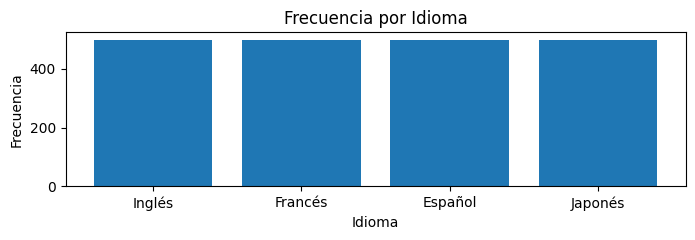

In [ ]:
# Grafico de frecuencias
plt.figure(figsize=(8, 2))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Idioma')
plt.ylabel('Frecuencia')
plt.title('Frecuencia por Idioma')
plt.show()

### **Exploración de los audios**

In [ ]:
train.element_spec

(TensorSpec(shape=(None, 160000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [ ]:
# Reproducir ejemplos de audios del dataset
labels_map = ['Español', 'Francés', 'Inglés', 'Japonés']
for audio, label_id in train_ds.take(1):
  for i in range(3):
    audio_np = audio[i]
    print(f"Audio {labels_map[label_id[i]]}\n")
    ipd.display(ipd.Audio(data=audio_np, rate=16000))
  break

Audio Japonés



Audio Francés



Audio Español



### **Grafico de ondas**

In [ ]:
# Tomar un lote del dataset y verificar la waveform
for waveform, label in train_ds.take(1):
    print(f"Forma del lote: {waveform.shape}")
    print(f"Forma de una waveform individual: {waveform[0].shape}")

Forma del lote: (16, 160000)
Forma de una waveform individual: (160000,)


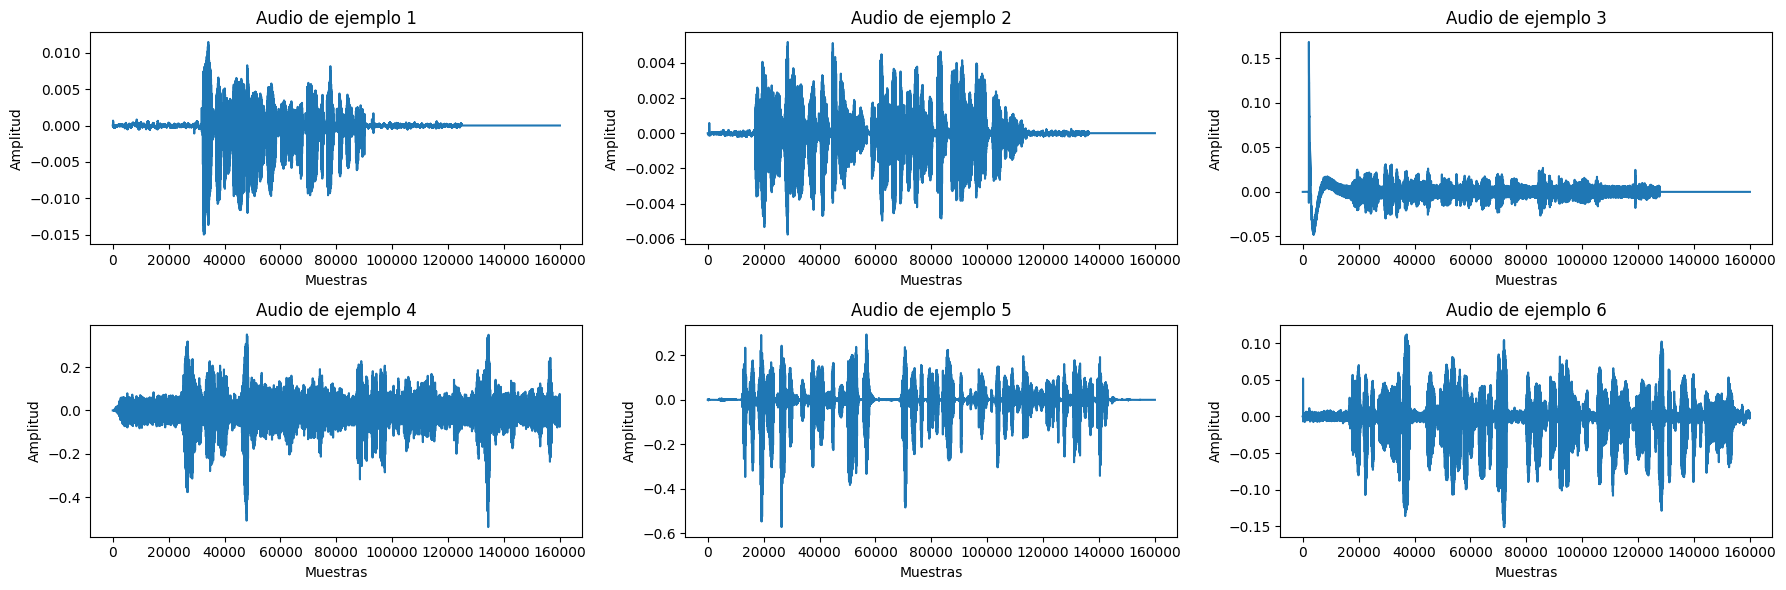

In [ ]:
# Tomar un ejemplo del dataset
i = 0
plt.figure(figsize=(18,6))
for audio, label in train_ds.take(1):
  for x in range(6):
    example_audio_np = audio[x]

    plt.subplot(2, 3, i+1)

    # Graficar la forma de onda
    plt.plot(example_audio_np)
    plt.title(f'Audio de ejemplo {i+1}')
    plt.xlabel('Muestras')
    plt.ylabel('Amplitud')

    i += 1
plt.tight_layout()
plt.show()

### **Convertir formas de onda a espectrogramas**

Las formas de onda del conjunto de datos están en el dominio del tiempo. Luego, se convierten al dominio tiempo-frecuencia mediante la transformada de Fourier de corto tiempo (STFT).

In [ ]:
# Tomar un lote del dataset y verificar la waveform
for waveform, label in train_ds.take(1):
    print(f"Forma del lote: {waveform.shape}")
    print(f"Forma de una waveform individual: {waveform[0].shape}")


Forma del lote: (16, 160000)
Forma de una waveform individual: (160000,)


In [ ]:
def get_spectrogram(waveform):
    # Aplicar STFT para obtener el espectrograma
    spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)

    # Calcular la magnitud del espectrograma (descartar la fase)
    spectrogram = tf.abs(spectrogram)

    # Añadir una dimensión extra para que sea compatible con la entrada del modelo (canal de color)
    spectrogram = spectrogram[..., tf.newaxis]

    # Redimensionar el espectrograma
    #spectrogram = tf.image.resize(spectrogram, [100, 970])

    return spectrogram

# Función para aplicar la conversión al dataset
def make_spec_ds(ds):
    return ds.map(
        map_func=lambda audio, label: (get_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE
    )

In [ ]:
# Aplicar la conversión de espectrograma a todo el dataset
train_spec_ds = make_spec_ds(train_ds)
val_spec_ds = make_spec_ds(val_ds)
test_spec_ds = make_spec_ds(test_ds)

for spec, label in train_spec_ds.take(1):
    print(f"Spectrogram shape: {spec.shape}, Label shape: {label.shape}")

Spectrogram shape: (16, 1249, 129, 1), Label shape: (16,)


In [ ]:
# Función para mostrar el espectrograma
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

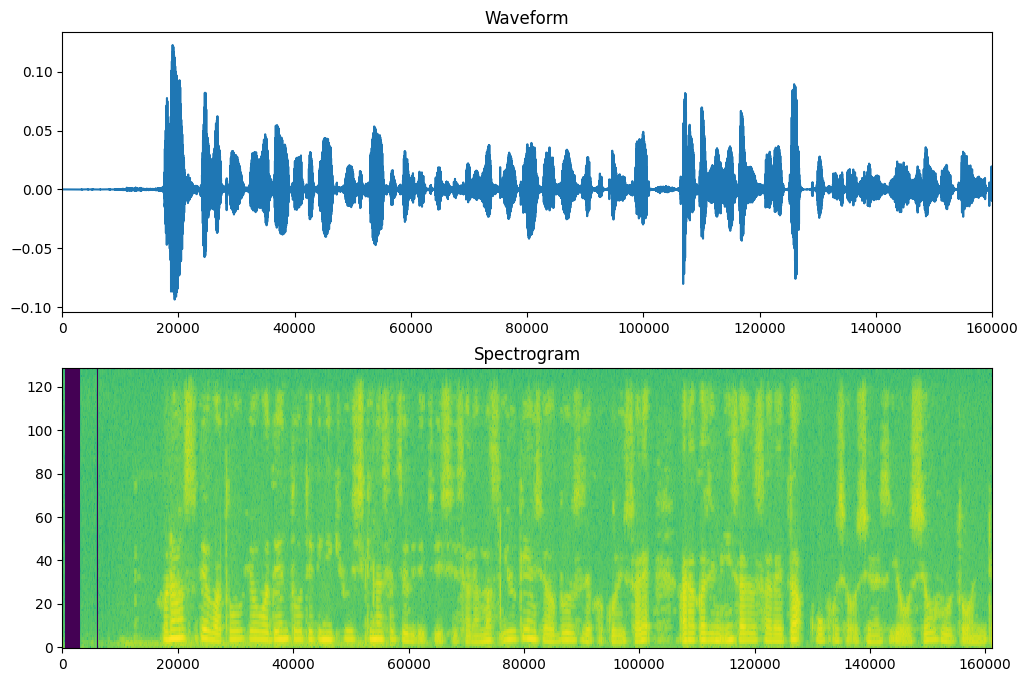

In [ ]:
# Plotear la onda y su respectivo espectrograma
for audio, label_id in train_ds.take(1):
  for i in range(1):
    waveform = audio[i]
    spectrogram_ = get_spectrogram(waveform)
    break

fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 160000])

plot_spectrogram(spectrogram_.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.show()

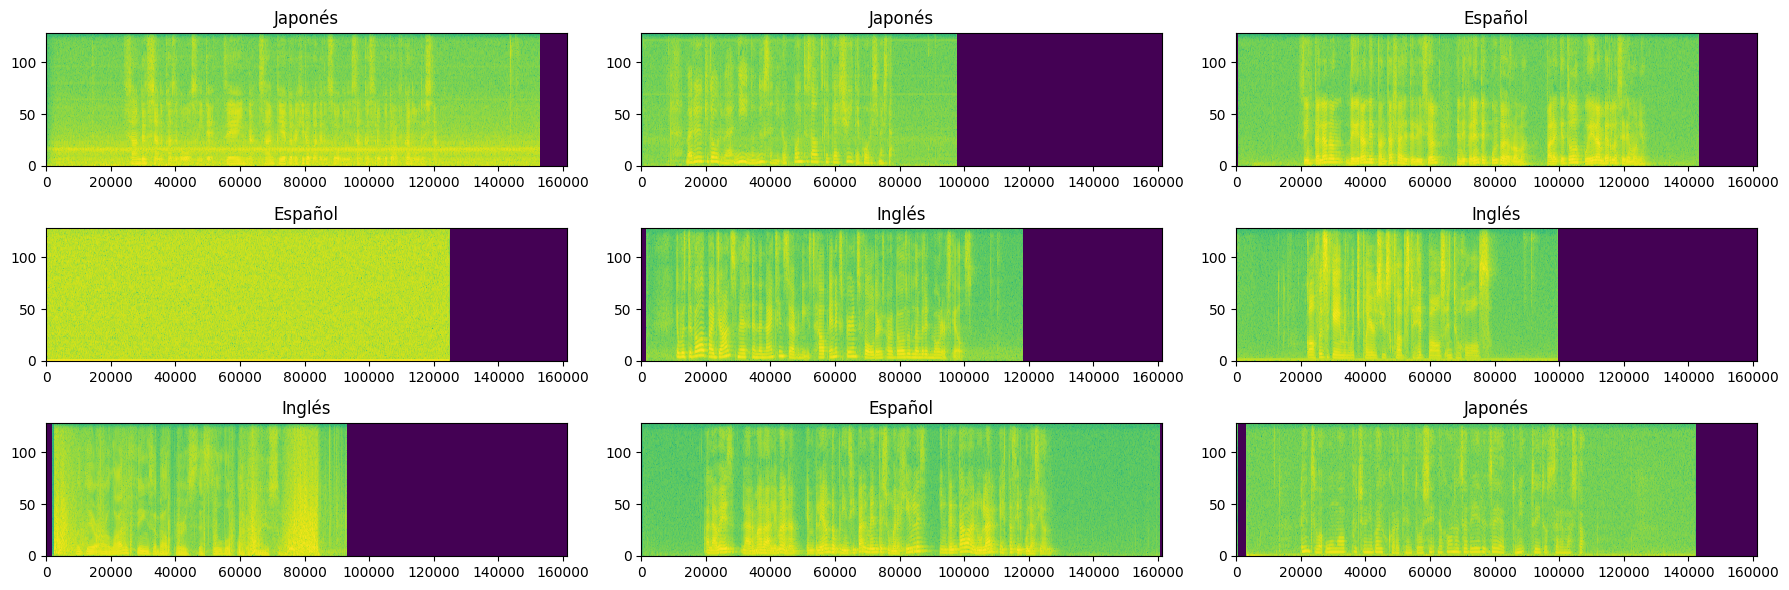

In [ ]:
# Plotear spectrogramas
for ex_spect, ex_spect_lbls in train_spec_ds.take(1):
  break

rows, cols = 3, 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 6))

for i in range(n):
    r, c = i // cols, i % cols
    ax = axes[r][c]
    plot_spectrogram(ex_spect[i].numpy(), ax)
    ax.set_title(label_names[ex_spect_lbls[i].numpy()])
plt.tight_layout()
plt.show()

## **Modelos**

### **Modelo convolucional sobre los espectrogramas de los clips**


In [ ]:
# Verificar la forma del spectrgrama
for spec, label in train_spec_ds.take(1):
    break
spec.shape[1:]

TensorShape([1249, 129, 1])

In [ ]:
# Definir las formas de entrada y la cantidad de etiquetas
input_shape = spec.shape[1:]
num_labels = 4

# Crear la capa de normalización
norm_layer = layers.Normalization()

# Adaptar la capa de normalización a los espectrogramas
norm_layer.adapt(train_spec_ds.map(lambda spec, label: spec))

In [ ]:
# Se optimiza la carga del dataset
train_spectrogram_ds = train_spec_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spec_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spec_ds.cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
# Definir el modelo
model = models.Sequential([
    layers.Input(shape=input_shape),

    # Reducir la resolución de la entrada.
    #layers.Resizing(420, 420, pad_to_aspect_ratio=True),

    # Normalizar
    norm_layer,

    # Primer bloque convolucional
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(pool_size=(6, 1)),
    layers.Dropout(0.5),

    # Aplanar para las capas densas
    layers.Flatten(),

    # Capa densa
    layers.Dense(48, activation='relu'),
    layers.Dropout(0.5),

    # Capa de salida
    layers.Dense(num_labels),
])

# Mostrar el resumen del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ normalization (Normalization)        │ (None, 1249, 129, 1)        │               3 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 1247, 127, 32)       │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 1245, 125, 32)       │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 207, 125, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 207, 125, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 828000)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 48)                  │      39,744,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             196 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,753,815 (151.65 MB)

 Trainable params: 39,753,812 (151.65 MB)

 Non-trainable params: 3 (16.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

epochs = 250
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=epochs,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=10),
)

Epoch 1/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 49s 227ms/step - accuracy: 0.3169 - loss: 4.4831 - val_accuracy: 0.4046 - val_loss: 1.2986
Epoch 2/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.4132 - loss: 1.2398 - val_accuracy: 0.6118 - val_loss: 1.0540
Epoch 3/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5538 - loss: 1.0321 - val_accuracy: 0.6645 - val_loss: 0.7896
Epoch 4/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.6288 - loss: 0.8823 - val_accuracy: 0.7039 - val_loss: 0.8033
Epoch 5/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.7127 - loss: 0.6632 - val_accuracy: 0.7434 - val_loss: 0.6514
Epoch 6/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.7624 - loss: 0.5463 - val_accuracy: 0.7237 - val_loss: 0.6969
Epoch 7/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.7642 - loss: 0.5550 - val_accuracy: 0.7763 - val_loss: 0.6132
Epoch 8/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.8114 - loss: 0.4539 - val_accurac

In [ ]:
test_loss, test_accuracy = model.evaluate(test_spectrogram_ds, verbose=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8999 - loss: 0.7541


In [ ]:
# Rutas para guardar el modelo entrenado
path_to_save_conv_model = '/content/drive/MyDrive/Aprendizaje 2/TP2'

# Guardar el modelo completo
model.save(f'{path_to_save_conv_model}/conv_model.keras')

# Guardar el history en formato JSON
with open(f'{path_to_save_conv_model}/conv_model_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
# Rutas para cargar el modelo entrenado
path_to_load_conv_model = '/content/drive/MyDrive/Aprendizaje 2/TP2/conv_model.keras'
path_to_load_history_conv_model = '/content/drive/MyDrive/Aprendizaje 2/TP2/conv_model_history.json'

# Cargar el modelo guardado
conv_model = tf.keras.models.load_model(path_to_load_conv_model)

# Cargar el history del modelo guardado
with open(path_to_load_history_conv_model, 'r') as f:
    conv_history = json.load(f)

Text(0, 0.5, 'Accuracy [%]')

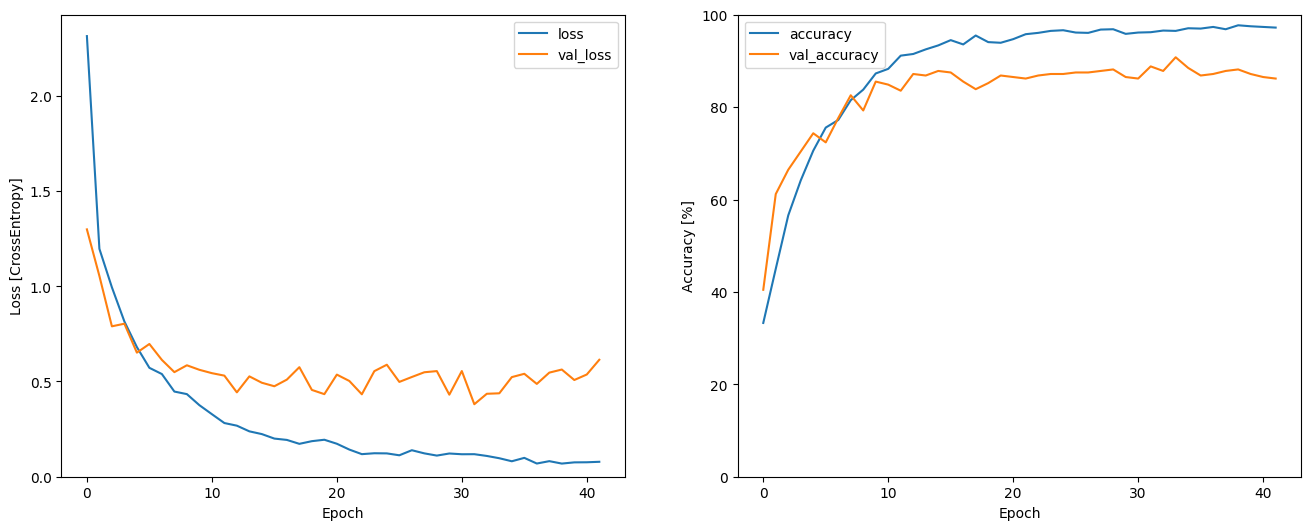

In [ ]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

**Interpretación:**

* El modelo aprende bien en entrenamiento, pero empieza a sobreajustarse a partir de cierto punto. La precisión en test ronda los 0.9.

*  La pérdida de entrenamiento disminuye constantemente, lo que indica que el modelo está aprendiendo. Sin embargo, la pérdida de validación no sigue una tendencia similar, y después de algunas épocas se concentra alrededor de un vaor mayor.

*  La precisión de entrenamiento aumenta de forma estable y alcanza valores altos, pero la precisión de validación es menor, mostrando un sobreajuste moderado.

**Reporte de clasificación:**

In [ ]:
y_pred = model.predict(test_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [ ]:
# Obtener el reporte de clasificación
label_names = np.array(train.class_names)
report = classification_report(y_true, y_pred, target_names=label_names)
print(report)

              precision    recall  f1-score   support

     Español       0.85      0.88      0.86        72
     Francés       0.88      0.88      0.88        84
      Inglés       0.83      0.81      0.82        73
     Japonés       0.93      0.93      0.93        67

    accuracy                           0.87       296
   macro avg       0.87      0.87      0.87       296
weighted avg       0.87      0.87      0.87       296



**Interpretación:**

*  En general, el modelo tiene un buen desempeño, con un accuracy general del 87%.

*  El japonés tiene el rendimiento más alto, con una precisión, recall y f1 de 0.93. Un recall bastante alto indica que se detectaron la mayoría de los casos reales.

*  El español y el francés tienen un buen rendimiento, con F1-scores por encima de 0.8.

*  El inglés es el idioma donde el modelo tiene más dificultad, con un F1-score de 0.82.

**Matriz de confusión**

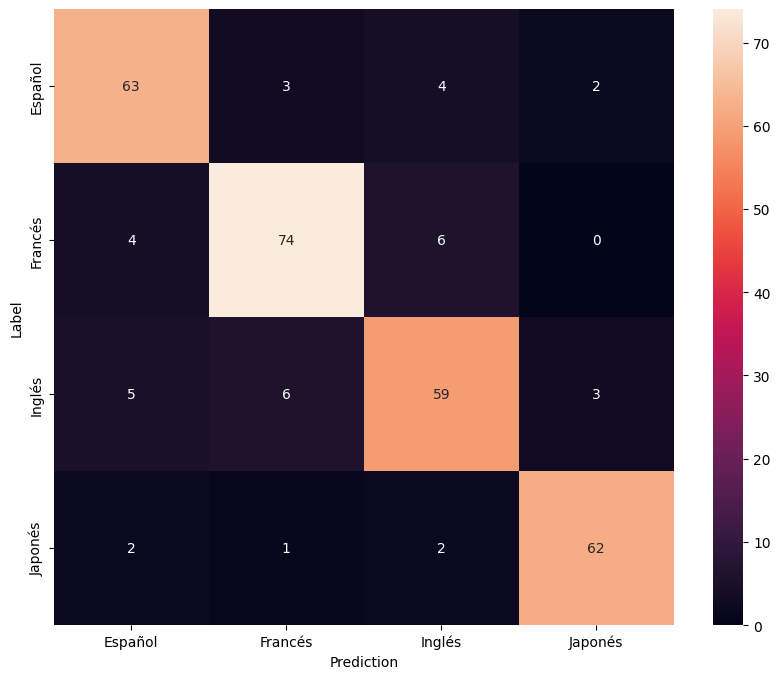

In [ ]:
label_names = np.array(train.class_names)
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

**Interpretación:**

* El inglés es el idioma con más falsos positivos (12).
* El japonés es el que mayor aciertos presenta, de un total de 67 ejemplos, solo cinco casos reales fueron clasificados de manera incorrecta, además es el que tiene menor cantidad de falsos positvos (5).



**Inferencia**

In [ ]:
# Función para inferir el lenguaje de un audio
def detect_lang(audio, model, label_names):
    # Leer archivo de audio
    x = tf.io.read_file(str(audio))
    x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=160000)

    # Eliminar la dimensión extra de canales
    x = tf.squeeze(x, axis=-1)
    waveform = x

    # Obtener el espectrograma
    x = get_spectrogram(x)
    x = x[tf.newaxis, ...]

    # Realizar la predicción
    prediction = model(x)
    predicted_lang_id = np.argmax(tf.nn.softmax(prediction[0]))
    lang_prob = np.max(tf.nn.softmax(prediction[0]))

    # Redondear la probabilidad a 2 decimales
    #lang_prob = np.round(lang_prob, 2)

    # Obtener el nombre del lenguaje predicho
    predicted_lang = label_names[predicted_lang_id]

    # Imprimir resultados
    print(f'El lenguaje detectado es {predicted_lang}\nProbabilidad: {lang_prob}\n')

    # Reproducir el audio
    ipd.display(ipd.Audio(waveform, rate=16000))

In [ ]:
# Realizar la inferencia
for language in ['Español', 'Francés', 'Inglés', 'Japonés']:
    language_folder = os.path.join(data_dir, language)

    # Obtener lista de archivos de audio en el idioma
    audio_files = [f for f in os.listdir(language_folder) if f.endswith(('.wav'))]

    # Seleccionar un archivo al azar
    selected_audio = random.choice(audio_files)
    selected_audio = os.path.join(language_folder, selected_audio)

    # Realizar predicción
    detect_lang(selected_audio, model, label_names)
    print("-----")

El lenguaje detectado es Español
Probabilidad: 0.9995717406272888



-----
El lenguaje detectado es Francés
Probabilidad: 0.9999998807907104



-----
El lenguaje detectado es Inglés
Probabilidad: 1.0



-----
El lenguaje detectado es Japonés
Probabilidad: 0.9491598010063171



-----


### **Modelo recurrente sobre los espectrogramas de los clips**

In [ ]:
for spec, label in val_spec_ds.take(1):
    print(f"Spectrogram shape: {spec.shape}, Label shape: {label.shape}")

Spectrogram shape: (16, 1249, 129, 1), Label shape: (16,)


In [ ]:
# Eliminar la dimensión extra
train_rnn_spect = train_spec_ds.map(squeeze, tf.data.AUTOTUNE)
val_rnn_spect = val_spec_ds.map(squeeze, tf.data.AUTOTUNE)
test_rnn_spect = test_spec_ds.map(squeeze, tf.data.AUTOTUNE)

for ex_audio, ex_labels in train_rnn_spect.take(1):
  print(f'Formato del audio: {ex_audio.shape}')
  print(f'Formato de las etiquetas: {ex_labels.shape}')

Formato del audio: (16, 1249, 129)
Formato de las etiquetas: (16,)


In [ ]:
# Definir las formas de entrada y la cantidad de etiquetas
INPUT_SHAPE = ex_audio.shape[1:]
NUM_LABELS = 4

# Crear la capa de normalización
norm_layer = layers.Normalization()

# Adaptar la capa de normalización a los espectrogramas
norm_layer.adapt(train_rnn_spect.map(lambda spec, label: spec))

In [ ]:
# Se optimiza la carga del dataset
train_rnn_prefetch = train_rnn_spect.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_rnn_prefetch = val_rnn_spect.cache().prefetch(tf.data.AUTOTUNE)
test_rnn_prefetch = test_rnn_spect.cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
# Modelo RNN para espectrogramas
rnn_model = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    # Normalización
    norm_layer,

    # Capas LSTM
    layers.LSTM(128,dropout=0.3, return_sequences=True),
    layers.LSTM(32, dropout=0.3),

    # Capa densa
    layers.Dense(64, activation='relu'),

    # Capa de salida
    layers.Dense(NUM_LABELS, activation='softmax'),
])

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization)      │ (None, 1249, 129)           │             259 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 1249, 128)           │         132,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 155,335 (606.78 KB)

 Trainable params: 155,076 (605.77 KB)

 Non-trainable params: 259 (1.02 KB)

In [ ]:
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

EPOCHS = 250
rnn_history = rnn_model.fit(
    train_rnn_prefetch,
    validation_data=val_rnn_prefetch,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=25),
)

Epoch 1/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - accuracy: 0.2830 - loss: 1.3803 - val_accuracy: 0.3224 - val_loss: 1.3592
Epoch 2/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.3519 - loss: 1.3189 - val_accuracy: 0.3026 - val_loss: 1.3424
Epoch 3/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.3480 - loss: 1.3070 - val_accuracy: 0.3520 - val_loss: 1.3139
Epoch 4/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.3550 - loss: 1.2520 - val_accuracy: 0.3355 - val_loss: 1.3583
Epoch 5/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.4080 - loss: 1.2382 - val_accuracy: 0.3257 - val_loss: 1.3579
Epoch 6/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.3716 - loss: 1.2518 - val_accuracy: 0.3750 - val_loss: 1.3332
Epoch 7/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.4081 - loss: 1.2187 - val_accuracy: 0.3750 - val_loss: 1.3457
Epoch 8/250
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.3926 - loss: 1.2277 - val_accuracy

In [ ]:
test_loss, test_accuracy = rnn_model.evaluate(test_rnn_prefetch, verbose=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.7307 - loss: 0.8845


In [ ]:
# Rutas para guardar el modelo entrenado
path_to_save_rnn_model = '/content/drive/MyDrive/Aprendizaje 2/TP2'

# Guardar el modelo completo
rnn_model.save(f'{path_to_save_rnn_model}/rnn_model.keras')

# Guardar el history en formato JSON
with open(f'{path_to_save_rnn_model}/rnn_model_history.json', 'w') as f:
    json.dump(rnn_history.history, f)

In [ ]:
# Rutas para cargar el modelo entrenado
path_to_load_rnn_model = '/content/drive/MyDrive/Aprendizaje 2/TP2/rnn_model.keras'
path_to_load_history_rnn_model = '/content/drive/MyDrive/Aprendizaje 2/TP2/rnn_model_history.json'

# Cargar el modelo guardado
rnn_model = tf.keras.models.load_model(path_to_load_rnn_model)

# Cargar el history del modelo guardado
with open(path_to_load_history_rnn_model, 'r') as f:
    rnn_history = json.load(f)

Text(0, 0.5, 'Accuracy [%]')

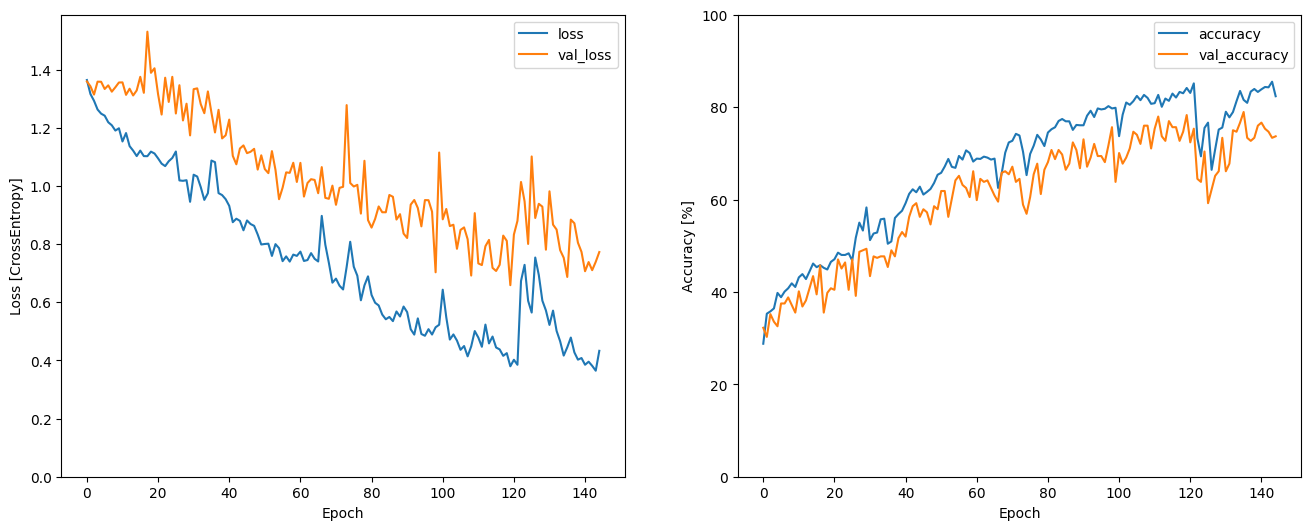

In [ ]:
metrics_rnn = rnn_history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(rnn_history.epoch, metrics_rnn['loss'], metrics_rnn['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(rnn_history.epoch, 100*np.array(metrics_rnn['accuracy']), 100*np.array(metrics_rnn['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

Interpretación:

El modelo aprende bien en entrenamiento, pero con un leve sobreajuste. La precisión en validación ronda el 80%.

La pérdida de entrenamiento y validación disminuyen constantemente, lo que indica que el modelo está aprendiendo.

La precisión de entrenamiento y validación aumentan relativamente estable con un poco de ruido y alcanzan valores altos, mostrando un pequeño sobreajuste.

### **Reporte de clasificación:**

In [ ]:
y_pred = rnn_model.predict(test_rnn_prefetch)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(test_rnn_prefetch.map(lambda s,lab: lab)), axis=0)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step


In [ ]:
# Obtener el reporte de clasificación
report = classification_report(y_true, y_pred, target_names=label_names)
print(report)

              precision    recall  f1-score   support

     Español       0.86      0.82      0.84        72
     Francés       0.82      0.74      0.78        84
      Inglés       0.62      0.71      0.66        73
     Japonés       0.87      0.87      0.87        67

    accuracy                           0.78       296
   macro avg       0.79      0.78      0.78       296
weighted avg       0.79      0.78      0.78       296



**Interpretación:**

*  El modelo tiene un desempeño relativamente bajo, con un accuracy general del 78%.

*  El japonés tiene el mejor rendimiento, con una precisión, recall y F1-scores del 0.87.

*  El español y el francés tienen un rendimiento considerable, con F1-scores por encima de 0.75, aunque ligeramente menor al japonés.

*  El inglés es el idioma donde el modelo tiene más dificultad, con un F1-score de 0.66.

### **Matriz de confusión**

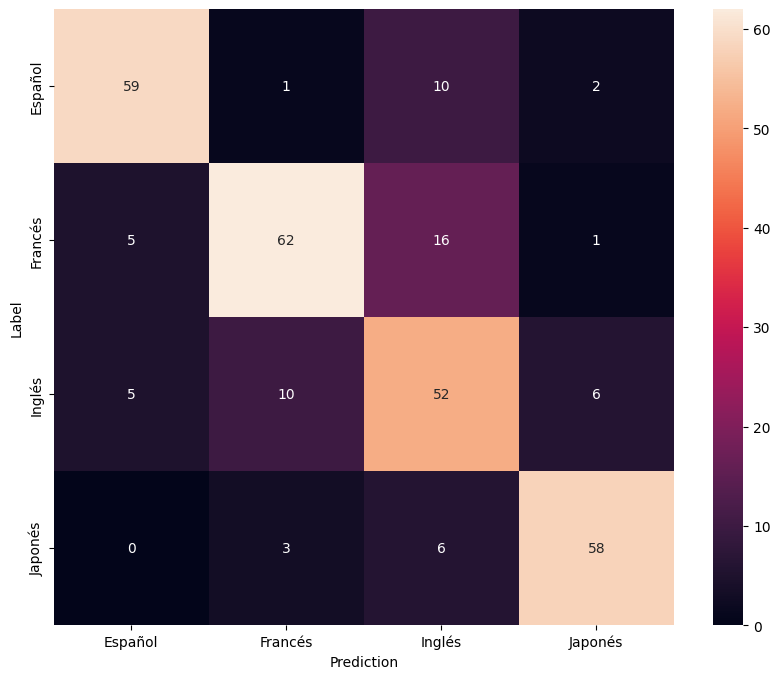

In [ ]:
label_names = np.array(train.class_names)
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

**Interpretación:**

* El inglés es el idioma con más falsos positivos (32).
* El japonés es el que mayor aciertos presenta, de un total de 67 ejemplos, solo nueve casos reales fueron clasificados de manera incorrecta, además es el que tiene menor cantidad de falsos positvos (9).

### **Inferencia**

In [ ]:
# Realizar la inferencia
for language in ['Español', 'Francés', 'Inglés', 'Japonés']:
    language_folder = os.path.join(data_dir, language)

    # Obtener lista de archivos de audio en el idioma
    audio_files = [f for f in os.listdir(language_folder) if f.endswith(('.wav'))]

    # Seleccionar un archivo al azar
    selected_audio = random.choice(audio_files)
    selected_audio = os.path.join(language_folder, selected_audio)

    # Realizar predicción
    detect_lang(selected_audio, rnn_model, label_names)
    print("-----")

El lenguaje detectado es Español
Probabilidad: 0.46663179993629456



-----
El lenguaje detectado es Francés
Probabilidad: 0.470635324716568



-----
El lenguaje detectado es Inglés
Probabilidad: 0.4565914273262024



-----
El lenguaje detectado es Japonés
Probabilidad: 0.462642103433609



-----


## **Conclusión**

Desplegué dos modelos con arquitecturas distintas para intentar inferir el idioma de un audio a partir de su espectrograma.

El modelo convolucional fue el que obtuvo el mejor desempeño. Después de probar diferentes configuraciones, logré alcanzar una precisión de aproximadamente 0.87. A pesar de aplicar varias técnicas para reducir el sobreajuste, no pude eliminarlo por completo. En este caso, el idioma que presentó mayores problemas fue el inglés, con una mayor tasa de falsos positivos. Por otro lado, el japonés fue el idioma que se detectó con mejor precisión.

El modelo recurrente tuvo un desempeño bastante bajo en comparación con el modelo convolucional, alcanzando una precisión de aproximadamente 0.78. Creo que el problema radica en cómo abordé los datos de entrada para la red, ya que utilicé los espectrogramas directamente sin intentar crear un patrón temporal entre ellos que pudiera beneficiarme de la capacidad de la arquitectura recurrente. En este caso también, el idioma japoés fue el que mejor rendimiento mostró durante la inferencia, mientras que el ingles presentó más dificultades.

Creo que un dataset más grande y un enfoque diferente en la preparación de las entradas para el modelo recurrente podrían mejorar las implementaciones y generar modelos más robustos.